# Read and analyse a UV Fits file


In [1]:
from astropy.time import Time
import numpy as np
import matplotlib.pyplot as plt
from pyuvdata import UVData

In [2]:
uvd_slice = UVData()
uvd_column = UVData()

uvd_slice.read("/home/olivia/oskareor.data/uvfits_templates/slice_uvw_plane.uvfits")
uvd_column.read("/home/olivia/oskareor.data/uvfits_templates/column_uvw_plane.uvfits")

The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 384.5154218594871 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.
The uvw_array does not match the expected values given the antenna positions. The largest discrepancy is 384.5154218594871 meters. This is a fairly common situation but might indicate an error in the antenna positions, the uvws or the phasing.


In [ ]:
def get_uvd_data(uvd):
    # get the data for a single baseline and polarization
    waterfall_data = uvd.get_data((1, 2, uvd.polarization_array[0]))
    # get the corresponding times for this waterfall
    waterfall_times = Time(
        uvd.get_times((1, 2, uvd.polarization_array[0])), format="jd"
    ).iso

    return waterfall_data, waterfall_times


def plot_uvd_data(uvd):
    waterfall_data, waterfall_times = get_uvd_data(uvd)

    # Amplitude waterfall for all spectral channels and 0th polarization
    fig, ax = plt.subplots(1, 1)
    _ = ax.imshow(np.abs(waterfall_data), interpolation="none", origin="lower")
    _ = ax.set_yticks([0, waterfall_times.size - 1])
    _ = ax.set_yticklabels([waterfall_times[0], waterfall_times[1]])
    freq_tick_inds = np.concatenate((np.arange(0, uvd.Nfreqs, 16), [uvd.Nfreqs - 1]))
    _ = ax.set_xticks(freq_tick_inds)
    _ = ax.set_xticklabels([f"{val:.3f}" for val in uvd.freq_array[freq_tick_inds] * 1e-9])
    _ = ax.set_xlabel("Frequency (GHz)")
    
    
    plt.show()

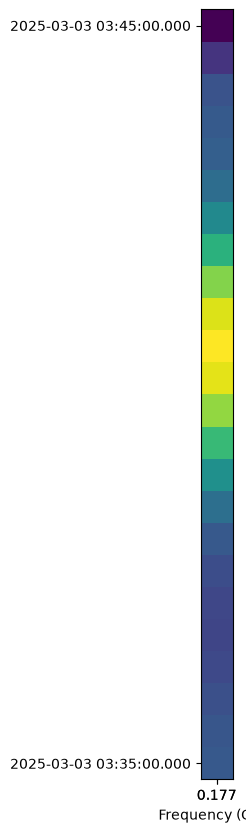

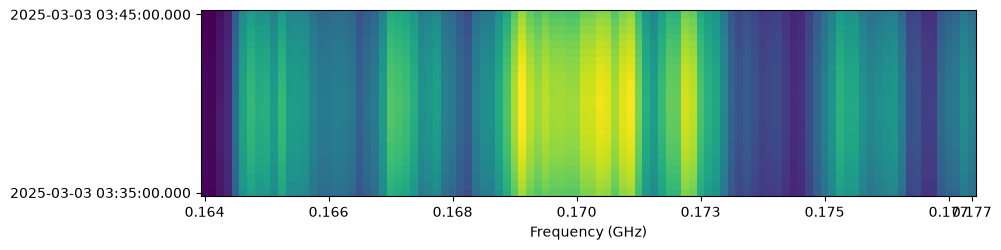

In [23]:
plot_uvd_data(uvd_slice)
plot_uvd_data(uvd_column)